In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import pickle as pkl
import os

In [11]:
model_folders = glob("results/synthetic_eq/*")
data = {}
for folder in model_folders:
    model_name = folder.split("/")[-1]
    with open(os.path.join(folder, "evaluation/eval_data.pkl"), "rb") as f:
        data[model_name] = pd.DataFrame(pkl.load(f))

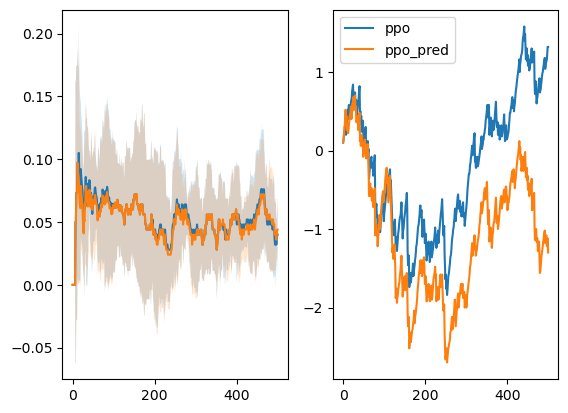

In [12]:
for key, value in data.items():
    df_mean = value.groupby("t").mean()
    df_std = value.groupby("t").std()

    plt.subplot(1, 2, 1)
    plt.plot(df_mean.index, df_mean["delta"], label=key)
    plt.fill_between(
        df_mean.index,
        df_mean["delta"] - df_std["delta"],
        df_mean["delta"] + df_std["delta"],
        alpha=0.2,
    )

    plt.subplot(1, 2, 2)
    plt.plot(df_mean.index, df_mean["bank_cash"], label = key)
    plt.legend()
    #plt.title(key)

    #plt.show()

